# Final analysis of the data

In this notebook, we will analyze the results obtained from the experiments about the 4 different algorithms: MLP, Random Forest KAN y QKAN. We will compare the results im terms of:
* AUC,
* Accuracy,
* Precision,
* Recall,
* Confusion Matrix, 
* Number of params, and
* Training time.

**About the dataset**

The dataset constains informations about ~340 000 samples of global features of jets generated by quarks and gluons. The dataset is balanced, with 50% of the samples being quark jets and 50% being gluon jets. The features are the global features:
- Transversal momentum
- eta
- mass
- multiplicity

The purpose of the experiments is to classify the jets as quark or gluon jets, and to compare the performance of the different algorithms in terms of the metrics mentioned above. Each feature were normalized 

In [1]:
import pandas as pd

In [2]:
metrics = pd.read_csv("../reports/raw_metrics_dataset.csv")

In [3]:
metrics.head(10)

,Model,Seed,Test AUC,Test Accuracy,Test F1 Score,Test Precision,Test Recall,Test Loss,Confusion Matrix,training_time_seconds,num_params
0,Classic KAN,42,0.874706,0.787124,0.783760,0.781114,0.786423,0.441603,"[[20946, 5642], [5468, 20134]]",271.897330,60.0
1,Classic KAN,123,0.870095,0.780667,0.775448,0.778916,0.772010,0.447912,"[[20978, 5610], [5837, 19765]]",1427.758782,120.0
2,Classic KAN,456,0.872444,0.785821,0.779718,0.786851,0.772713,0.445363,"[[21229, 5359], [5819, 19783]]",1258.243691,120.0
3,Classic KAN,789,0.870918,0.782372,0.778320,0.777834,0.778806,0.446622,"[[20893, 5695], [5663, 19939]]",384.207529,60.0
4,Classic KAN,1024,0.872926,0.784901,0.781127,0.779819,0.782439,0.443949,"[[20932, 5656], [5570, 20032]]",586.549296,75.0
5,Classic KAN,2048,0.873458,0.786032,0.781669,0.782541,0.780798,0.443072,"[[21033, 5555], [5612, 19990]]",521.961697,75.0
6,Classic KAN,4096,0.869109,0.781203,0.777038,0.776871,0.777205,0.449392,"[[20873, 5715], [5704, 19898]]",501.597311,75.0
7,Classic KAN,8192,0.872770,0.787488,0.782755,0.785077,0.780447,0.444224,"[[21118, 5470], [5621, 19981]]",804.945365,90.0
8,Classic KAN,16384,0.876053,0.789212,0.785910,0.783152,0.788688,0.439316,"[[20997, 5591], [5410, 20192]]",782.524387,90.0
9,Classic KAN,32768,0.876210,0.786549,0.782778,0.781559,0.784001,0.438375,"[[20978, 5610], [5530, 20072]]",432.143013,75.0


In [4]:
# prueba de hipotesis que auc de QKAN es mayor que auc de mlp
from scipy.stats import ttest_ind
auc_qkan = metrics[metrics["Model"] == "QKAN (Noisy)"]["Test AUC"]
auc_mlp = metrics[metrics["Model"] == "Classic MLP"]["Test AUC"]
t_stat, p_value = ttest_ind(auc_qkan, auc_mlp, alternative='greater')

print(f"T-statistic: {t_stat}, P-value: {p_value}")
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: AUC de QKAN es significativamente mayor que AUC de MLP.")
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar que AUC de QKAN es mayor que AUC de MLP.")

T-statistic: 2.1746161369615926, P-value: 0.02161848301093693
Rechazamos la hipótesis nula: AUC de QKAN es significativamente mayor que AUC de MLP.


In [5]:
# prueba de hipotesis que auc de QKAN es mayor que auc de mlp usando ttest_rel
from scipy.stats import ttest_rel
auc_qkan = metrics[metrics["Model"] == "QKAN (Noisy)"]["Test AUC"]
auc_mlp = metrics[metrics["Model"] == "Classic MLP"]["Test AUC"]
t_stat, p_value = ttest_rel(auc_qkan, auc_mlp, alternative='greater')

print(f"T-statistic: {t_stat}, P-value: {p_value}")
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: AUC de QKAN es significativamente mayor que AUC de MLP.")
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar que AUC de QKAN es mayor que AUC de MLP.")

T-statistic: 2.739808783177806, P-value: 0.011427362011013853
Rechazamos la hipótesis nula: AUC de QKAN es significativamente mayor que AUC de MLP.


In [6]:
# prueba de hipotesis que auc de QKAN es mayor que auc de mlp usando Mann-Whitney U test
from scipy.stats import mannwhitneyu
auc_qkan = metrics[metrics["Model"] == "QKAN (Noisy)"]["Test AUC"]
auc_mlp = metrics[metrics["Model"] == "Classic MLP"]["Test AUC"]
u_stat, p_value = mannwhitneyu(auc_qkan, auc_mlp, alternative='greater')

print(f"U-statistic: {u_stat}, P-value: {p_value}")
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: AUC de QKAN es significativamente mayor que AUC de MLP.")
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar que AUC de QKAN es mayor que AUC de MLP.")

U-statistic: 75.0, P-value: 0.032011050641513446
Rechazamos la hipótesis nula: AUC de QKAN es significativamente mayor que AUC de MLP.


In [7]:
# prueba estadística sobre relevancia de la diferencia entre AUCs usando Cohen's d
def cohen_d(x, y):
    x = x.dropna()
    y = y.dropna()
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = (((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof) ** 0.5
    return (x.mean() - y.mean()) / pooled_std

auc_qkan = metrics[metrics["Model"] == "QKAN (Noisy)"]["Test AUC"]
auc_mlp = metrics[metrics["Model"] == "Classic MLP"]["Test AUC"]
d = cohen_d(auc_qkan, auc_mlp)
print(f"Cohen's d: {d}")
if d < 0.2:
    print("La diferencia entre AUCs es pequeña.")
elif d < 0.5:
    print("La diferencia entre AUCs es mediana.")
else:
    print("La diferencia entre AUCs es grande.")

Cohen's d: 0.972517901442823
La diferencia entre AUCs es grande.


In [12]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = lambda key: matplotlib.rcParams.get(key)
%matplotlib inline

/tmp/ipykernel_40183/3903631319.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


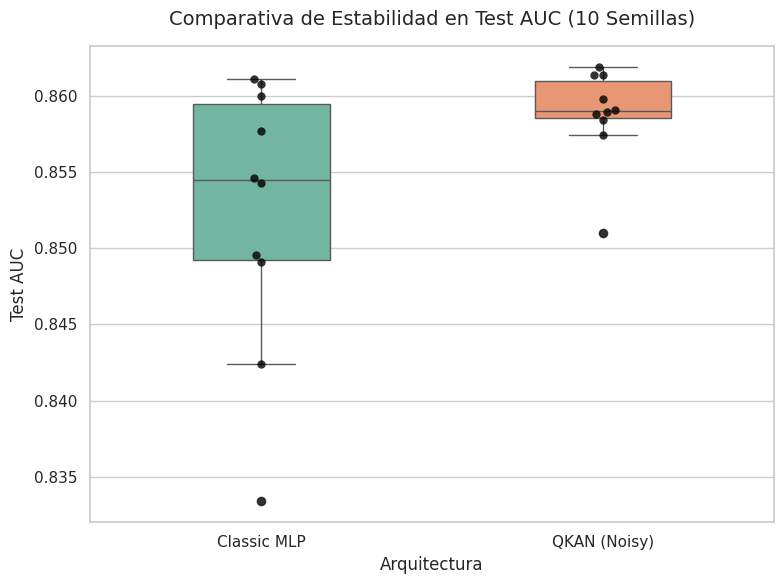

In [ ]:
# 1. Filtramos solo los dos modelos que te interesan
df_filtrado = metrics[metrics["Model"].isin(["Classic MLP", "QKAN (Noisy)"])]

# 2. Configuramos el estilo
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))

# 3. Dibujamos el Boxplot (cajas semi-transparentes para ver la estadística)
sns.boxplot(
    data=df_filtrado, 
    x="Model", 
    y="Test AUC", 
    palette="Set2", 
    width=0.4
)

# 4. Dibujamos los 10 puntos reales encima (para total transparencia científica)
sns.swarmplot(
    data=df_filtrado, 
    x="Model", 
    y="Test AUC", 
    color="black", 
    alpha=0.8, 
    size=6
)

# 5. Etiquetas y título
plt.title("Comparativa de estabilidad en Test AUC (10 Semillas)", fontsize=14, pad=15)
plt.ylabel("Test AUC", fontsize=12)
plt.xlabel("Arquitectura", fontsize=12)

# Opcional: Ajustar los límites del eje Y para que no se vea cortado
# plt.ylim(0.80, 0.90) 

plt.tight_layout()
plt.show()